# H3 - Floors vs Lot Size

**Hypothesis (William Rodriguez - City House):**
Houses in more central, city-like areas tend to have more floors but smaller lot sizes. This compact, vertical style is what William's city house should look like.

**Research question:** Do houses with more floors tend to sit on smaller lots?

We will check this step by step: look at the data, explore the two columns we care about (`floors`, `sqft_lot`), clean up extreme outliers, and then test the relationship.

## 1. Understanding the Data

We load the dataset and take a first look at the two columns relevant to H3.

In [2]:
# import the libraries we need for this notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# load the dataset
df = pd.read_csv("data/eda.csv")

# show the first few rows to get an overview
df.head()

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


We also add the `location_type` feature (same rule used in the H1 notebook): houses in zip codes 98038, 98042 or 98023 are labeled `Rural`, all other zip codes are labeled `Urban`.

In [3]:
# same rural zip codes as used in the H1 notebook
rural_zipcodes = [98038, 98042, 98023]

# add a location_type column: 'Rural' for those zip codes, 'Urban' for everything else
df["location_type"] = df["zipcode"].apply(
    lambda z: "Rural" if z in rural_zipcodes else "Urban"
)

# check how many houses fall into each category
df["location_type"].value_counts()

location_type
Urban    19962
Rural     1635
Name: count, dtype: int64

In [4]:
# quick summary statistics for the two columns we care about in H3
df[["floors", "sqft_lot"]].describe()

,floors,sqft_lot
count,21597.000000,2.159700e+04
mean,1.494096,1.509941e+04
std,0.539683,4.141264e+04
min,1.000000,5.200000e+02
25%,1.000000,5.040000e+03
50%,1.500000,7.618000e+03
75%,2.000000,1.068500e+04
max,3.500000,1.651359e+06


In [5]:
# check for missing values in the columns we need for H3
df[["floors", "sqft_lot"]].isna().sum()

floors      0
sqft_lot    0
dtype: int64

## 2. Exploring the Data

Before testing anything, we look at how `floors` and `sqft_lot` are distributed on their own.

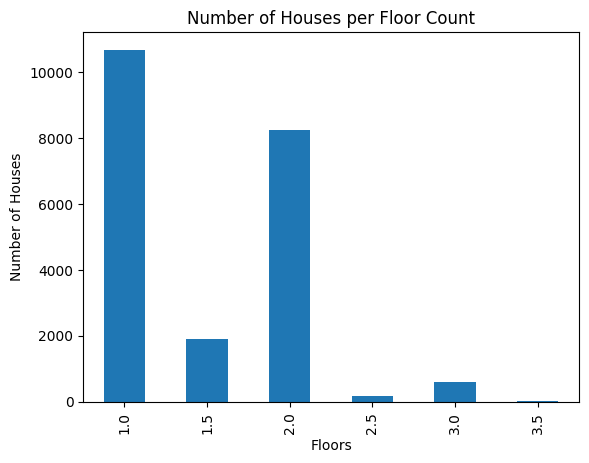

In [6]:
# floors is a discrete/categorical-like value (1, 1.5, 2, ...)
# a bar chart of value counts shows how common each floor count is
df["floors"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Houses per Floor Count")
plt.xlabel("Floors")
plt.ylabel("Number of Houses")
plt.show()

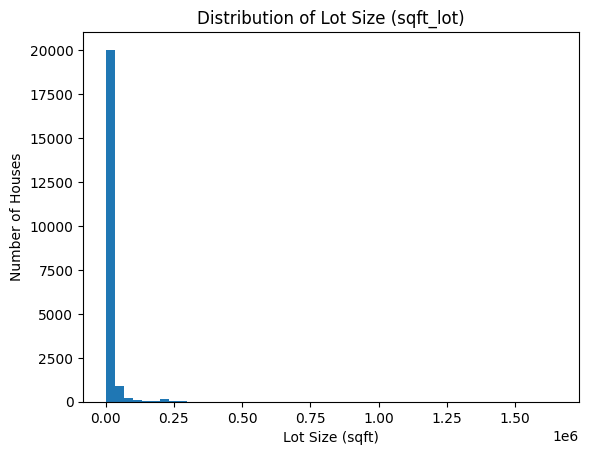

In [7]:
# sqft_lot is continuous, so a histogram is a good way to see its distribution
df["sqft_lot"].plot(kind="hist", bins=50)
plt.title("Distribution of Lot Size (sqft_lot)")
plt.xlabel("Lot Size (sqft)")
plt.ylabel("Number of Houses")
plt.show()

The histogram is heavily skewed to the right: most houses have a small lot, but a few houses have a very large lot and stretch out the x-axis. These extreme values are outliers we should handle before comparing groups.

## 3. Cleaning the Data

We remove the most extreme `sqft_lot` outliers (the top 1%) so a handful of very large lots don't distort our plots and test.

In [8]:
# find the value below which 99% of the lot sizes fall
upper_limit = df["sqft_lot"].quantile(0.99)

# keep only rows with a lot size below that limit
df_clean = df[df["sqft_lot"] < upper_limit].copy()

# how many rows did we drop?
rows_dropped = len(df) - len(df_clean)
print(f"Dropped {rows_dropped} rows ({rows_dropped / len(df):.1%} of the data) as extreme lot-size outliers.")

Dropped 217 rows (1.0% of the data) as extreme lot-size outliers.


## 4. Relationships in the Data

Now we look at how `floors` and `sqft_lot` relate to each other, using the cleaned data.

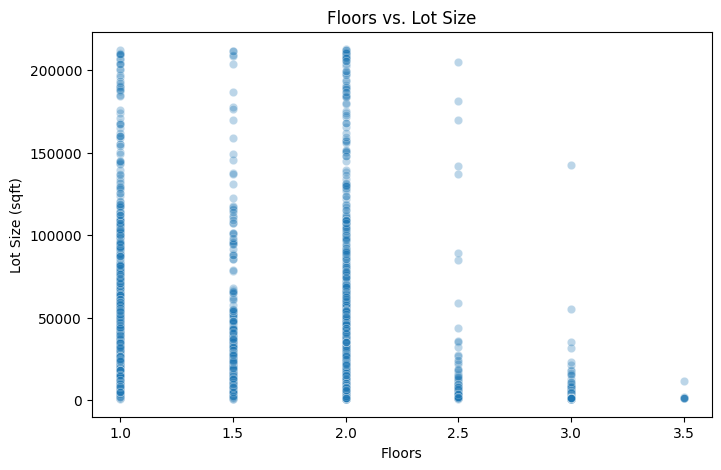

In [9]:
# scatterplot: does lot size tend to shrink as floors increase?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="floors", y="sqft_lot", alpha=0.3)
plt.title("Floors vs. Lot Size")
plt.xlabel("Floors")
plt.ylabel("Lot Size (sqft)")
plt.show()

In [10]:
# Spearman correlation between floors and lot size, for ALL houses
# a negative value means: more floors tends to go together with a smaller lot
corr_all, p_value_all = spearmanr(df_clean["floors"], df_clean["sqft_lot"])

print("All houses:")
print(f"Spearman correlation: {corr_all:.3f}")
print(f"p-value: {p_value_all:.5f}")

All houses:
Spearman correlation: -0.242
p-value: 0.00000


Both plots suggest that houses with more floors tend to have smaller lots. To check this more formally, we use a **Spearman correlation**. It measures whether two variables move together in a consistent direction (up or down), which fits `floors` well since it only has a few discrete values (1, 1.5, 2, 2.5, 3, 3.5).

### 4.1 Zooming in on Urban Houses

William's city house should sit in an urban, central area. So we now repeat the same plots and test, but only for houses where `location_type` is `Urban`, and compare the result to the all-houses result above.

In [11]:
# keep only urban houses (using the cleaned data from step 3)
df_urban = df_clean[df_clean["location_type"] == "Urban"].copy()

print(f"Number of urban houses: {len(df_urban)} (out of {len(df_clean)} total)")

Number of urban houses: 19772 (out of 21380 total)


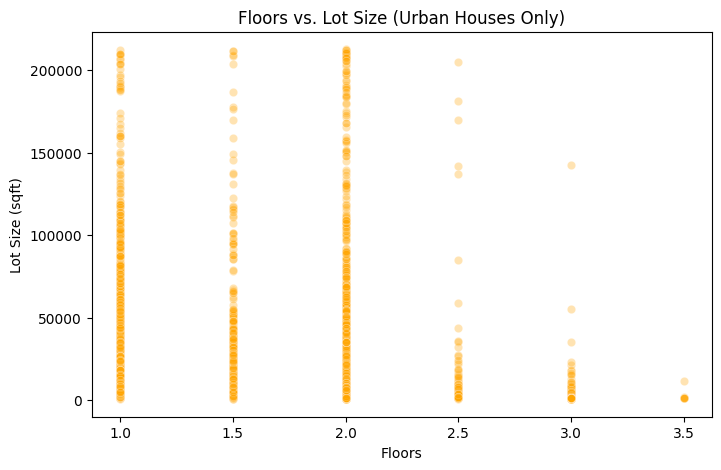

In [12]:
# same scatterplot as before, but for urban houses only
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_urban, x="floors", y="sqft_lot", alpha=0.3, color="orange")
plt.title("Floors vs. Lot Size (Urban Houses Only)")
plt.xlabel("Floors")
plt.ylabel("Lot Size (sqft)")
plt.show()

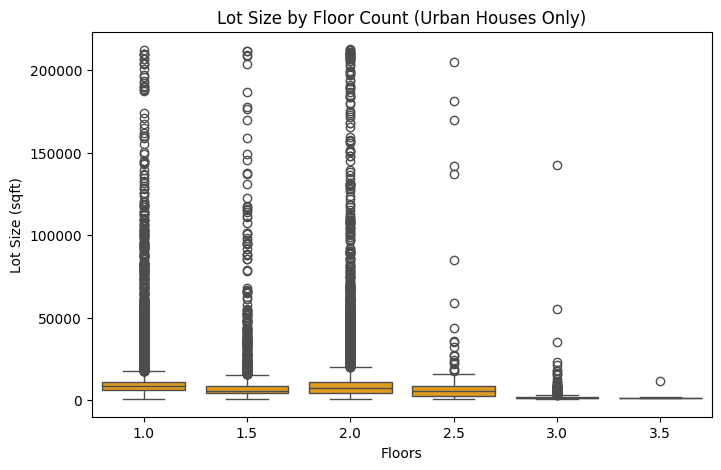

In [13]:
# same boxplot as before, but for urban houses only
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_urban, x="floors", y="sqft_lot", color="orange")
plt.title("Lot Size by Floor Count (Urban Houses Only)")
plt.xlabel("Floors")
plt.ylabel("Lot Size (sqft)")
plt.show()

In [14]:
# Spearman correlation between floors and lot size
# a negative value means: more floors tends to go together with a smaller lot
corr, p_value = spearmanr(df_clean["floors"], df_clean["sqft_lot"])

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p_value:.5f}")

Spearman correlation: -0.242
p-value: 0.00000


**How to read this:**
- The correlation is between -1 and 1. A negative number close to -1 means a strong tendency for lot size to shrink as floors increase, which would support H3.
- The p-value tells us whether this result is likely just random noise. A p-value below 0.05 means the relationship is unlikely to be a coincidence.

Compare the printed numbers above to these rules of thumb to decide whether the data supports H3 for William's city house search.